In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/WELFake_Dataset.csv')
print("Shape:", df.shape)
print("\nLabel counts:")
print(df['label'].value_counts())
df.head(3) 



Matplotlib is building the font cache; this may take a moment.


Shape: (72134, 4)

Label counts:
label
1    37106
0    35028
Name: count, dtype: int64


,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1


Missing values:
 Unnamed: 0      0
title         558
text           39
label           0
dtype: int64

After cleaning: (71537, 4)


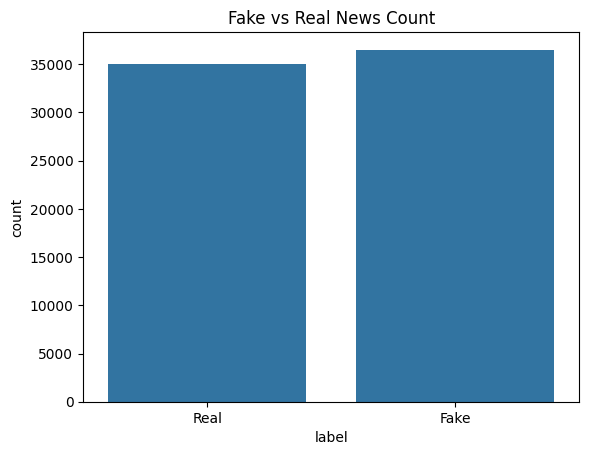

In [3]:
# Check missing values and clean
print("Missing values:\n", df.isnull().sum())
df = df.dropna()
print("\nAfter cleaning:", df.shape)

# Plot fake vs real
sns.countplot(x='label', data=df)
plt.xticks([0,1], ['Real','Fake'])
plt.title('Fake vs Real News Count')
plt.savefig('../models/label_chart.png')
plt.show()

In [4]:
import re
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = [w for w in text.split() if w not in stop_words]
    return ' '.join(words)

print("Cleaning text... (takes ~30 seconds)")
df['clean'] = df['text'].apply(clean_text)
print("Done!")
print(df['clean'].head(2))

Cleaning text... (takes ~30 seconds)
Done!
0    comment expected barack obama members fyf fuky...
2    demonstrators gathered last night exercising c...
Name: clean, dtype: str


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import pickle

X = df['clean']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print("Train shape:", X_train_tfidf.shape)
print("Test shape: ", X_test_tfidf.shape)

with open('../models/data.pkl', 'wb') as f:
    pickle.dump((X_train_tfidf, X_test_tfidf, y_train, y_test, tfidf), f)
print("Saved!")

Train shape: (57229, 5000)
Test shape:  (14308, 5000)
Saved!


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Naive Bayes':         MultinomialNB(),
    'Decision Tree':       DecisionTreeClassifier(max_depth=10)
}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, preds)
    print(f"{name}: {acc*100:.2f}%")

Logistic Regression: 94.95%
Naive Bayes: 85.04%
Decision Tree: 91.45%


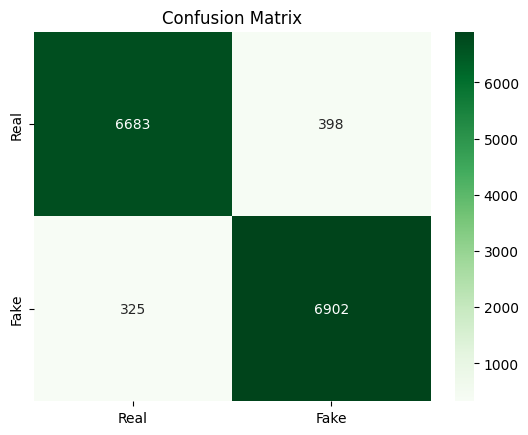

              precision    recall  f1-score   support

        Real       0.95      0.94      0.95      7081
        Fake       0.95      0.96      0.95      7227

    accuracy                           0.95     14308
   macro avg       0.95      0.95      0.95     14308
weighted avg       0.95      0.95      0.95     14308



In [7]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pickle

# Use best model
best = LogisticRegression(max_iter=1000)
best.fit(X_train_tfidf, y_train)
preds = best.predict(X_test_tfidf)

# Save model
with open('../models/best_model.pkl', 'wb') as f:
    pickle.dump(best, f)

# Confusion matrix
cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Real','Fake'], yticklabels=['Real','Fake'])
plt.title('Confusion Matrix')
plt.savefig('../models/confusion_matrix.png')
plt.show()

print(classification_report(y_test, preds, target_names=['Real','Fake']))

In [8]:
import re
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

def predict(text):
    text = re.sub(r'[^a-z\s]', '', text.lower())
    text = ' '.join([w for w in text.split() if w not in stop_words])
    vec  = tfidf.transform([text])
    pred = best.predict(vec)[0]
    prob = best.predict_proba(vec)[0]
    label = "🚨 FAKE" if pred == 1 else "✅ REAL"
    print(f"{label}  —  {max(prob)*100:.1f}% confident")

predict("Scientists discover cure for cancer using bananas")
predict("Federal Reserve raises interest rates by 0.25 percent")

🚨 FAKE  —  90.0% confident
🚨 FAKE  —  66.7% confident
